In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')
import warnings
from py_code import XGB_test_model
from py_code import CNN1D_test_model
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch
from pathlib import Path

In [2]:
txt_dir = Path("output_files_ML/HAWCSim_array/test_protons/100300TeV_030deg_4FF_180R175h_Black/")

protons_info = []

for txt_file in txt_dir.glob("*.txt"):
    name = txt_file.stem   
    txt_file_name = str(txt_file)
    rc, pr, y_te, p_te  = np.loadtxt(txt_file_name).T    
    protons_info.append((p_te.tolist(),y_te.tolist()))

In [3]:
def calculate_smd(hist1, hist2):

    hist1 = np.asarray(hist1)
    hist2 = np.asarray(hist2)
    
    mean1 = np.mean(hist1)
    mean2 = np.mean(hist2)
    
    s1 = np.std(hist1)
    s2 = np.std(hist2)
    
    std = np.sqrt((s1**2 + s2**2) / 2)
    
    if std == 0:
        return np.nan
    
    return (mean1 - mean2) / std

In [4]:
"""def find_best_threshold(protons_info : list):

    smds = []
        
    thresholds = np.linspace(0, 1, 100)
    for t in thresholds:

        hist_protons = []
        hist_gammas = []
        for i in range(len(protons_info)):

            info_single_proton = protons_info[i]

            p_proton = np.asarray(info_single_proton[0])
            y_proton = np.asarray(info_single_proton[1])
         
            p_gamma = p_proton[y_proton == 0]
            
            p_proton_above_cut = np.sum(p_proton[p_proton >= t])
            p_gamma_above_cut  = np.sum(p_gamma[p_gamma >= t])
        
            hist_protons.append(p_proton_above_cut)
            hist_gammas.append(p_gamma_above_cut)

        smd = calculate_smd(hist_protons, hist_gammas)
        smds.append(smd)
        
    plt.plot(thresholds, smds, color = "red", linestyle = "--", label = "SMD")
    plt.xlabel("Threshold", fontsize = 24)
    plt.ylabel("SMD", fontsize = 24)
    plt.legend(loc = "best")
    plt.show()
        
    best_index = np.nanargmax(smds)
    best_threshold = thresholds[best_index]
    print("Best threshold = ", best_threshold)
    print("SMD @ best threshold = ", smds[best_index])
    return best_threshold, smds[best_index]"""

'def find_best_threshold(protons_info : list):\n\n    smds = []\n\n    thresholds = np.linspace(0, 1, 100)\n    for t in thresholds:\n\n        hist_protons = []\n        hist_gammas = []\n        for i in range(len(protons_info)):\n\n            info_single_proton = protons_info[i]\n\n            p_proton = np.asarray(info_single_proton[0])\n            y_proton = np.asarray(info_single_proton[1])\n\n            p_gamma = p_proton[y_proton == 0]\n\n            p_proton_above_cut = np.sum(p_proton[p_proton >= t])\n            p_gamma_above_cut  = np.sum(p_gamma[p_gamma >= t])\n\n            hist_protons.append(p_proton_above_cut)\n            hist_gammas.append(p_gamma_above_cut)\n\n        smd = calculate_smd(hist_protons, hist_gammas)\n        smds.append(smd)\n\n    plt.plot(thresholds, smds, color = "red", linestyle = "--", label = "SMD")\n    plt.xlabel("Threshold", fontsize = 24)\n    plt.ylabel("SMD", fontsize = 24)\n    plt.legend(loc = "best")\n    plt.show()\n\n    best_index

In [5]:
def find_best_threshold(protons_info, target_eff = 0.8):

    fprs = []
    thresholds = np.linspace(0, 1, 50)
    
    for t in thresholds:

        hist_protons = []
        hist_gammas = []
        for i in range(len(protons_info)):
            
            info_single = protons_info[i]

            p_proton = np.asarray(info_single[0])
            y = np.asarray(info_single[1])
    
            p_gamma = p_proton[y == 0]
    
            p_proton_above_cut = np.sum(p_proton[p_proton >= t])
            p_gamma_above_cut  = np.sum(p_gamma[p_gamma >= t])

            hist_protons.append(p_proton_above_cut)
            hist_gammas.append(p_gamma_above_cut)
    
        thresh = np.percentile(hist_gammas, target_eff * 100)
    
        proton_fpr = np.sum(hist_protons <= thresh) / len(hist_protons)
    
        fprs.append(proton_fpr)

    best_index = np.nanargmin(fprs)
    best_threshold = thresholds[best_index]
    min_fpr = fprs[best_index]

    print(f"Gamma efficiency target = {target_eff}")
    print(f"Min FPR = {min_fpr}")
    print(f"Best_threshold FPR = {best_threshold}")

    return best_threshold, min_fpr

In [6]:
best_threshold, min_fpr = find_best_threshold(protons_info)

Gamma efficiency target = 0.8
Min FPR = 0.2436332767402377
Best_threshold FPR = 0.8571428571428571


In [7]:
hist_protons = []
hist_gammas = []

for i in range(len(protons_info)):
    info_single_proton = protons_info[i]
    
    p_proton = np.asarray(info_single_proton[0])
    y_proton = np.asarray(info_single_proton[1])
    
    p_gamma = p_proton[y_proton == 0]
    
    p_proton_above_cut = np.sum(p_proton[p_proton >= best_threshold])
    p_gamma_above_cut  = np.sum(p_gamma[p_gamma >= best_threshold])
    
    hist_protons.append(p_proton_above_cut)
    hist_gammas.append(p_gamma_above_cut)

Mean Protons =  9.373088285229201
Mean Gammas =  4.318445670628183
SMD =  1.4252817022570272
Gamma 80% threshold =  6.363200000000001
Number of protons in 80% gamma region =  287
Fraction of protons kept =  0.2436332767402377


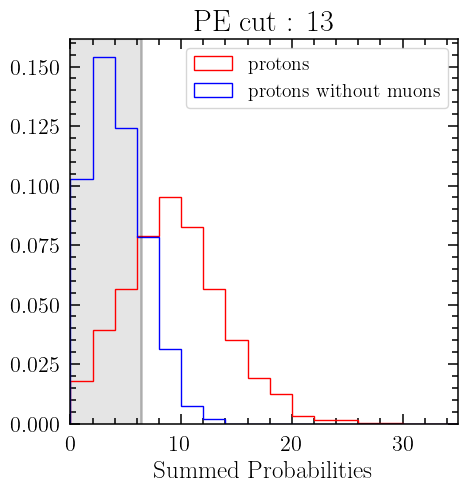

Mean Protons =  9.373088285229201
Mean Gammas =  4.318445670628183
SMD =  1.4252817022570272
Gamma 80% threshold =  6.363200000000001
Number of protons in 80% gamma region =  287
Fraction of protons kept =  0.2436332767402377


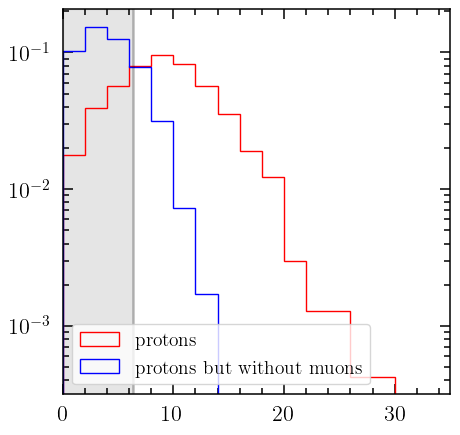

In [8]:
gammas = np.array(hist_gammas)
protons = np.array(hist_protons)

threshold = np.percentile(gammas, 80)

protons_in_region = protons[(protons >= 0) & (protons <= threshold)]

print("Mean Protons = ", np.mean(hist_protons))
print("Mean Gammas = ", np.mean(hist_gammas))
print("SMD = ", calculate_smd(hist_protons, hist_gammas))
print("Gamma 80% threshold = ", threshold)
print("Number of protons in 80% gamma region = ", len(protons_in_region))
print("Fraction of protons kept = ", len(protons_in_region)/len(protons))

plt.hist(hist_protons, color="red", histtype="step", label="protons", density = True, range = (0,60), bins = 30)
plt.hist(hist_gammas, color="blue", histtype="step", label="protons without muons", density = True, range = (0,60), bins = 30)

#plt.yscale("log")
plt.xlim(0,35)
plt.xlabel("Summed Probabilities")
plt.title(r"PE cut : 13")
plt.axvspan(0, threshold, alpha = 0.1, color = "black")
plt.axvline(threshold, color = "black", linestyle = "-", alpha = 0.2)

plt.legend()
plt.savefig("/swgo/Simulazioni/gamma_hadron.png", dpi = 300)

plt.show()

gammas = np.array(hist_gammas)
protons = np.array(hist_protons)

threshold = np.percentile(gammas, 80)

protons_in_region = protons[(protons >= 0) & (protons <= threshold)]

print("Mean Protons = ", np.mean(hist_protons))
print("Mean Gammas = ", np.mean(hist_gammas))
print("SMD = ", calculate_smd(hist_protons, hist_gammas))
print("Gamma 80% threshold = ", threshold)
print("Number of protons in 80% gamma region = ", len(protons_in_region))
print("Fraction of protons kept = ", len(protons_in_region)/len(protons))

plt.hist(hist_protons, color="red", histtype="step", label="protons", density = True, range = (0,60), bins = 30)
plt.hist(hist_gammas, color="blue", histtype="step", label="protons but without muons", density = True, range = (0,60), bins = 30)

plt.yscale("log")
plt.xlim(0,35)
plt.axvspan(0, threshold, alpha = 0.1, color = "black")
plt.axvline(threshold, color = "black", linestyle = "-", alpha = 0.2)


plt.legend()
plt.show()

In [9]:
def get_S_to_B_ratio(gammas: np.ndarray, protons: np.ndarray):
    
    S_list = []
    B_list = []
    S_to_sqrtB_list = []

    for percentile in np.linspace(0, 1, 30):
        thresh = np.percentile(gammas, percentile*100)  

        S = np.sum(gammas <= thresh) / len(gammas)
        B = np.sum(protons <= thresh) / len(protons)
        
        S_list.append(S)
        B_list.append(B)

        if B > 0:
            S_to_sqrtB_list.append(S / np.sqrt(B))
        else:
            S_to_sqrtB_list.append(0)

    return S_list, S_to_sqrtB_list

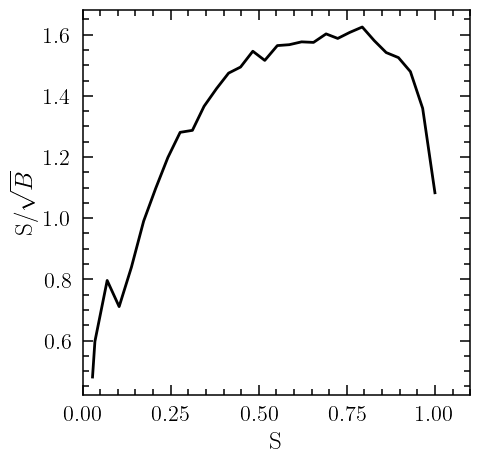

In [10]:
S, S_to_sqrtB_list = get_S_to_B_ratio(gammas, protons)

plt.plot(S, S_to_sqrtB_list, color = "black", linestyle = "-")

plt.xlim(0,1.1)
plt.xlabel(r"S")
plt.ylabel(r"S/$\sqrt{B}$")


plt.show()

Fit results:
a = 0.20751977405142832 +/- 0.007850710556895592
b = 1.884907479984212 +/- 0.27667674876940984
Chi2 = 18.90282389922417
ndf = 12
Chi2/ndf = 1.5752353249353475


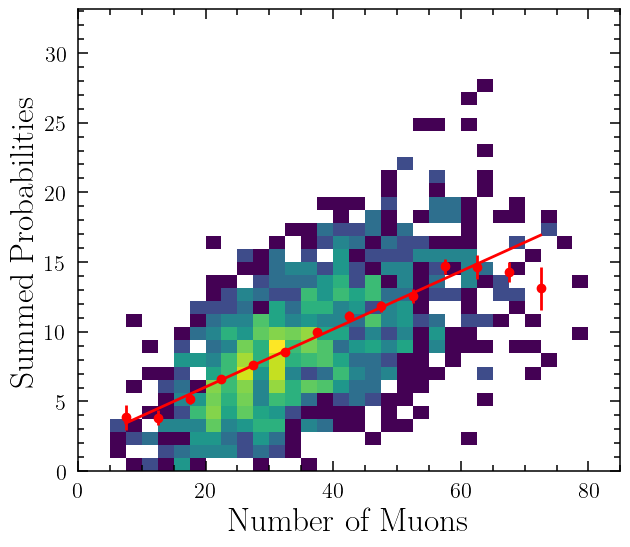

In [11]:
import matplotlib.colors as colors
from iminuit import Minuit
n_muons = []
p_cum = []

for i in range(len(protons_info)):
    
    info_single_proton = protons_info[i]
    
    p_proton = np.asarray(info_single_proton[0])
    y_proton = np.asarray(info_single_proton[1])

    #y_proton = y_proton[p_proton >= best_threshold]
    p_proton = p_proton[p_proton >= best_threshold]

        
    n_muons_proton = np.nansum(y_proton == 1)
    p_cum_proton = np.nansum(p_proton)

    n_muons.append(n_muons_proton)
    p_cum.append(p_cum_proton)

n_muons = np.asarray(n_muons)
p_cum = np.asarray(p_cum)

bin_width = 5
n_min = np.min(n_muons)
n_max = np.max(n_muons)

bins = np.arange(n_min, n_max + bin_width, bin_width)
bin_centers = []
mean_pr = []
err_pr = []
p_bin_centers = []

for i in range(len(bins) - 1):
    p_in_bin = []
    mask_bin = (n_muons >= bins[i]) & (n_muons < bins[i+1])
    p_cum_bin = p_cum[mask_bin]
    
    if len(p_cum_bin) > 5:
        bin_centers.append(0.5 * (bins[i] + bins[i+1]))
        p_in_bin.append(p_cum_bin)
        mean_pr.append(np.mean(p_cum_bin))
        err_pr.append(np.std(p_cum_bin) / np.sqrt(len(p_cum_bin)))  
    p_bin_centers.append(p_in_bin)

bin_centers = np.asarray(bin_centers)
mean_pr = np.asarray(mean_pr)
err_pr = np.asarray(err_pr)

def linear_regr(x, a, b):
    return a * x + b

def chi2(a, b):
    return np.sum(((mean_pr - linear_regr(bin_centers, a, b)) / err_pr) ** 2)


m = Minuit(chi2, a = 1.0, b = 0.0)
m.errordef = Minuit.LEAST_SQUARES

m.migrad()
m.hesse()

print("Fit results:")
print("a =", m.values["a"], "+/-", m.errors["a"])
print("b =", m.values["b"], "+/-", m.errors["b"])

chi2_val = m.fval
ndf = len(mean_pr) - len(m.parameters)
print("Chi2 =", chi2_val)
print("ndf =", ndf)
print("Chi2/ndf =", chi2_val / ndf)

plt.figure(figsize = (7,6))
plt.errorbar(bin_centers, mean_pr, yerr = err_pr, fmt='o', color = "red")

n_fit = np.linspace(min(bin_centers), max(bin_centers), 100)
p_fit = linear_regr(n_fit, *m.values)



plt.plot(n_fit, p_fit, color = "red")
plt.xlabel("Number of Muons", fontsize = 24)
plt.ylabel("Summed Probabilities", fontsize = 24)
plt.hist2d(n_muons, p_cum, bins = 30, cmap = "viridis",  norm=colors.LogNorm(vmin=1))
plt.xlim(0,n_max + 5)
plt.ylim(0, np.max(p_cum) + 5)
#plt.savefig("/swgo/Simulazioni/prob_vs_muons.png", dpi = 300)

plt.show()

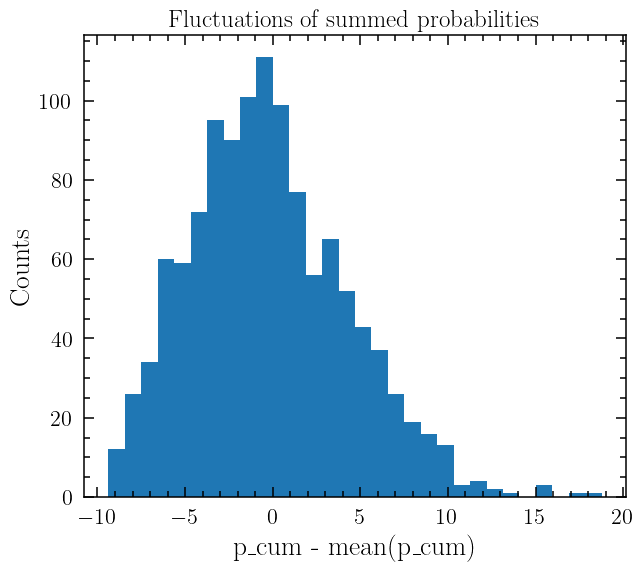

In [12]:
# Compute mean
p_mean = np.mean(p_cum)

# Centered values
p_centered = p_cum - p_mean

plt.figure(figsize=(7,6))

# Histogram
plt.hist(p_centered, bins=30)

plt.xlabel("p_cum - mean(p_cum)", fontsize=20)
plt.ylabel("Counts", fontsize=20)

plt.title("Fluctuations of summed probabilities", fontsize=18)

plt.show()

Mean number of muons =  35.54668930390493


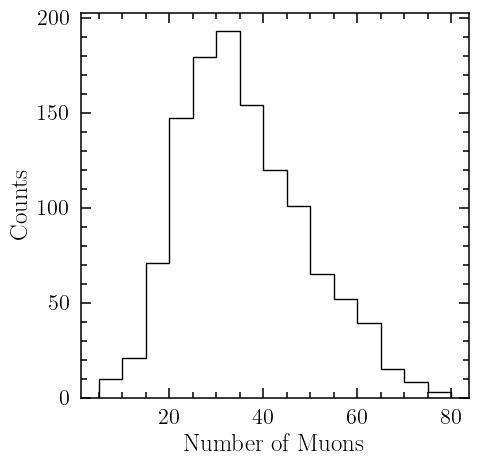

In [13]:
plt.hist(n_muons, color = "black", histtype = "step", bins = 15)
print("Mean number of muons = ", np.mean(n_muons))
plt.xlabel("Number of Muons")
plt.ylabel("Counts")
plt.show()

In [14]:
def n_estimated(m, q, p):
    a = 1/m
    b = -q/m
    return a*p + b

In [15]:
m_ = m.values[0]
q = m.values[1]
print("m = ", m.values[0])
print("q = ", m.values[1]) 

def estimator(n_reco_, n_muons_):
    return 1 - n_reco/n_muons

m =  0.20751977405142832
q =  1.884907479984212


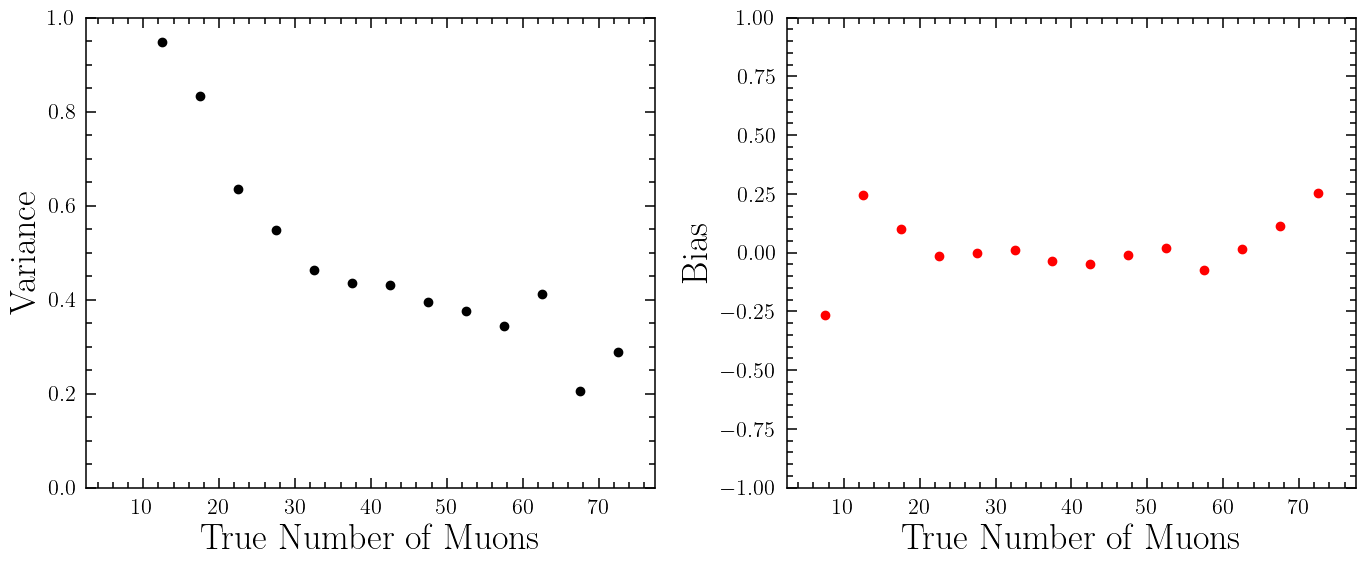

In [16]:
est_list = []
for i in range(len(bin_centers)): 
    est = [1 - (n_estimated(m_, q, p_bin_centers[i][j])/bin_centers[i]) for j in range(len(p_bin_centers[i]))]
    est_list.append(est)
variance = [np.std(k) for k in est_list]
bias = [np.mean(k) for k in est_list]

fig, ax = plt.subplots(1, 2, figsize=(14,6))

ax[0].scatter(bin_centers, variance, label="variance", color="black")
ax[1].scatter(bin_centers, bias, label="bias", color="red")

ax[0].set_xlabel("True Number of Muons", fontsize=26)
ax[1].set_xlabel("True Number of Muons", fontsize=26)

ax[0].set_ylabel("Variance", fontsize=26)
ax[1].set_ylabel("Bias", fontsize=26)

ax[0].set_xlim(np.min(bin_centers)-5, np.max(bin_centers) + 5)
ax[1].set_xlim(np.min(bin_centers)-5, np.max(bin_centers) + 5)
ax[0].set_ylim(0, 1)
ax[1].set_ylim(-1, 1)

plt.tight_layout()
#plt.savefig("/swgo/Simulazioni/bias_and_reso.png", dpi = 300)
plt.show()



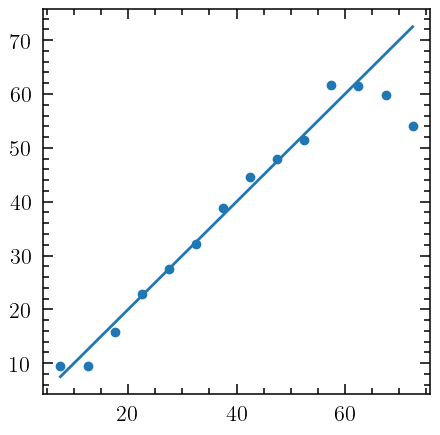

In [17]:
reco_list = []
for i in range(len(bin_centers)): 
    n_recos = [(n_estimated(m_, q, p_bin_centers[i][j])) for j in range(len(p_bin_centers[i]))]
    reco_list.append(np.mean(n_recos))
n_true = bin_centers
plt.scatter(n_true, reco_list)
plt.plot(n_true, n_true)
plt.show()

Delta N statistics:
Bias (mean) = 0.5
68% width = 33.0


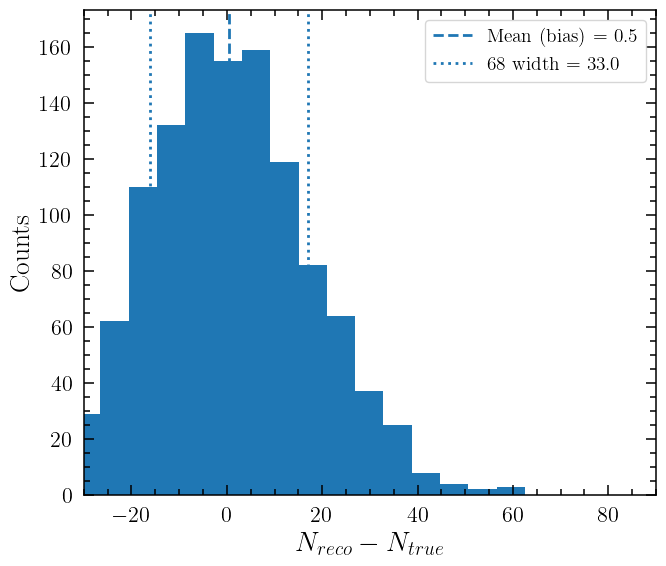

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Build event-by-event ΔN
# -------------------------
delta_n = []

for i in range(len(protons_info)):
    
    info_single_proton = protons_info[i]
    
    p_proton = np.asarray(info_single_proton[0])
    y_proton = np.asarray(info_single_proton[1])

    #y_proton = y_proton[p_proton >= best_threshold]
    p_proton = p_proton[p_proton >= best_threshold]

    n_true = np.nansum(y_proton == 1)
    p_cum = np.nansum(p_proton)
    
    if n_true > 0:
        n_reco = n_estimated(m_, q, p_cum)
        n_reco = float(np.asarray(n_reco).ravel()[0])
        
        delta_n.append(n_reco - n_true)

delta_n = np.asarray(delta_n)

# -------------------------
# Statistics
# -------------------------
bias = np.mean(delta_n)

p16 = np.percentile(delta_n, 16)
p84 = np.percentile(delta_n, 84)

width_68 = p84 - p16   # FULL amplitude

print("Delta N statistics:")
print(f"Bias (mean) = {bias:.1f}")
print(f"68% width = {width_68:.1f}")

# -------------------------
# Plot histogram
# -------------------------
plt.figure(figsize=(7,6))

plt.hist(delta_n, bins=20)

# Mean line
plt.axvline(bias, linestyle='--', linewidth=2)

# 68% interval
plt.axvline(p16, linestyle=':', linewidth=2)
plt.axvline(p84, linestyle=':', linewidth=2)

plt.xlabel(r"$N_{reco} - N_{true}$", fontsize=20)
plt.ylabel("Counts", fontsize=20)
plt.xlim(-30,90)
# Legend with amplitude
plt.legend([
    f"Mean (bias) = {bias:.1f}",
    f"68 width = {width_68:.1f}"
])

#plt.savefig("/swgo/Simulazioni/reco_minus_true.pdf", dpi = 300)
plt.tight_layout()
plt.show()